In [155]:
from langchain_groq import ChatGroq # Initialize LLM (Using Groq's Mixtral Model)
llm = ChatGroq(
    model="qwen-2.5-32b",
    api_key="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"
)


In [156]:


def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b



In [159]:
tools = [add, multiply, divide]

In [161]:
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

In [163]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

# Node
def assistant(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

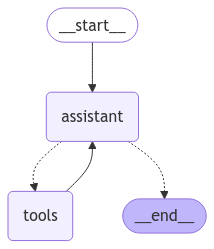

In [165]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [179]:
from langchain.schema import HumanMessage
messages = [HumanMessage(content="add 3 + 4. ")]


In [181]:
messages = react_graph.invoke({"messages": messages})

In [182]:
print(messages)

{'messages': [HumanMessage(content='add 3 + 4. ', additional_kwargs={}, response_metadata={}, id='38408208-61c1-4bd0-a829-f5592448dd3d'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_abx7', 'function': {'arguments': '{"a": 3, "b": 4}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 351, 'total_tokens': 376, 'completion_time': 0.063404801, 'prompt_time': 0.018781536, 'queue_time': 0.258774964, 'total_time': 0.082186337}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-3125a78c-501a-4bb8-bc94-9ebe0c9df815-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 4}, 'id': 'call_abx7', 'type': 'tool_call'}], usage_metadata={'input_tokens': 351, 'output_tokens': 25, 'total_tokens': 376}), ToolMessage(content='7', name='add', id='de1c9761-b142-4cbf-81a7-e56d109c7502', tool_call_id='call_abx7'), AIMessage(content='The sum of 3

In [185]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

add 3 + 4. 
================================== Ai Message ==================================
Tool Calls:
  add (call_abx7)
 Call ID: call_abx7
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================

The sum of 3 and 4 is 7.


In [187]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

In [189]:
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:
    
    # Often, we will use state to decide on the next node to visit
    user_input = state['graph_state'] 
    
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"
    
    # 50% of the time, we return Node 3
    return "node_3"

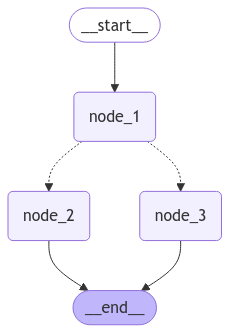

In [195]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [197]:
graph.invoke({"graph_state" : "Hi, this is Lance."})

---Node 1---
---Node 2---


{'graph_state': 'Hi, this is Lance. I am happy!'}

In [199]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

In [201]:
llm_with_tools = llm.bind_tools([multiply])

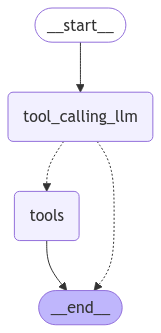

In [203]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode([multiply]))
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [209]:
from langchain_core.messages import HumanMessage
messages = [HumanMessage(content="Hello, what is 2 multiplied by 2? .")]
messages = graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, what is 2 multiplied by 2? .
================================== Ai Message ==================================
Tool Calls:
  multiply (call_sjvk)
 Call ID: call_sjvk
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: multiply

4


In [212]:
import sqlite3
# In memory
conn = sqlite3.connect(":memory:", check_same_thread = False)

In [214]:
db_path = "state_db/example.db"
conn = sqlite3.connect(db_path, check_same_thread=False)

OperationalError: unable to open database file

In [230]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Sumit\Downloads\nba.csv")
df.head(2)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0.0,PG,25.0,6-2,180.0,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99.0,SF,25.0,6-6,235.0,Marquette,6796117.0


In [232]:
import sqlite3
import pandas as pd

# Read the CSV file (make sure to use a raw string or escaped backslashes)
df = pd.read_csv(r"C:\Users\Sumit\Downloads\nba.csv")

# Create (or open) an SQLite database connection.
# In this example, we create a file called "nba_data.db" in the current directory.
conn = sqlite3.connect("nba_data.db")

# Write the DataFrame to an SQL table named 'nba'. If the table already exists, it will be replaced.
df.to_sql("nba", conn, if_exists="replace", index=False)

# Optionally, query the new table to confirm it was written correctly.
sql_df = pd.read_sql("SELECT * FROM nba LIMIT 5", conn)
print(sql_df)

# Close the connection when you're done.
conn.close()


            Name            Team  Number Position   Age Height  Weight  \
0  Avery Bradley  Boston Celtics     0.0       PG  25.0    6-2   180.0   
1    Jae Crowder  Boston Celtics    99.0       SF  25.0    6-6   235.0   
2   John Holland  Boston Celtics    30.0       SG  27.0    6-5   205.0   
3    R.J. Hunter  Boston Celtics    28.0       SG  22.0    6-5   185.0   
4  Jonas Jerebko  Boston Celtics     8.0       PF  29.0   6-10   231.0   

             College     Salary  
0              Texas  7730337.0  
1          Marquette  6796117.0  
2  Boston University        NaN  
3      Georgia State  1148640.0  
4               None  5000000.0  


In [236]:
import sqlite3
import pandas as pd

# Read the CSV file (make sure to use a raw string or escaped backslashes)
df = pd.read_csv(r"C:\Users\Sumit\Downloads\nba.csv")

# Create (or open) an SQLite database connection.
# In this example, we create a file called "nba_data.db" in the current directory.
conn = sqlite3.connect("nba_data.db")

# Write the DataFrame to an SQL table named 'nba'. If the table already exists, it will be replaced.
df.to_sql("nba", conn, if_exists="replace", index=False)

# Optionally, query the new table to confirm it was written correctly.
sql_df = pd.read_sql("SELECT * FROM nba LIMIT 5", conn)
print(sql_df)




            Name            Team  Number Position   Age Height  Weight  \
0  Avery Bradley  Boston Celtics     0.0       PG  25.0    6-2   180.0   
1    Jae Crowder  Boston Celtics    99.0       SF  25.0    6-6   235.0   
2   John Holland  Boston Celtics    30.0       SG  27.0    6-5   205.0   
3    R.J. Hunter  Boston Celtics    28.0       SG  22.0    6-5   185.0   
4  Jonas Jerebko  Boston Celtics     8.0       PF  29.0   6-10   231.0   

             College     Salary  
0              Texas  7730337.0  
1          Marquette  6796117.0  
2  Boston University        NaN  
3      Georgia State  1148640.0  
4               None  5000000.0  


In [248]:
# Custom Graph implementation mimicking langraph functionality

class Graph:
    def __init__(self):
        self.nodes = {}  # Dictionary to store node functions and metadata
        self.edges = {}  # Dictionary to store outgoing edges for each node

    def add_node(self, name, func, description='', stateful=False):
        """Register a node with its processing function and metadata."""
        self.nodes[name] = {
            'func': func,
            'description': description,
            'stateful': stateful
        }
        if name not in self.edges:
            self.edges[name] = []

    def add_edge(self, source, destination, condition=None):
        """Create an edge from source to destination, optionally with a condition."""
        if source not in self.edges:
            self.edges[source] = []
        self.edges[source].append({'destination': destination, 'condition': condition})

    def run(self, start_node, state):
        """
        Execute the graph starting from 'start_node'.
        The state dictionary is passed and updated by each node.
        """
        current_node = start_node
        while True:
            if current_node not in self.nodes:
                raise ValueError(f"Node '{current_node}' not found in the graph.")
            # Execute the node's function and update the state.
            state = self.nodes[current_node]['func'](state)
            
            # If no outgoing edges, stop execution.
            if current_node not in self.edges or not self.edges[current_node]:
                break

            # Determine the next node based on edge conditions.
            next_node_found = False
            for edge in self.edges[current_node]:
                condition = edge.get('condition')
                if condition is None or condition(state):
                    current_node = edge['destination']
                    next_node_found = True
                    break
            if not next_node_found:
                break
        return state

In [238]:
# Here is our checkpointer 
from langgraph.checkpoint.sqlite import SqliteSaver
memory = SqliteSaver(conn)

ModuleNotFoundError: No module named 'langgraph.checkpoint.sqlite'

In [250]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

def llm_extract_intent(state):
    """
    Node: LLM Extract Intent
    Extracts intent from the input text and updates the state.
    """
    input_text = state.get("input", "")
    if "help" in input_text.lower():
        state["intent"] = "help"
    elif "weather" in input_text.lower():
        state["intent"] = "weather"
    else:
        state["intent"] = "unknown"
    return state

def gate(state):
    """
    Node: Gate
    Evaluates the current state to decide whether to continue processing.
    If the intent is 'unknown', sets a flag in the state to exit.
    """
    state["exit"] = state.get("intent") == "unknown"
    return state

def llm_generate_response(state):
    """
    Node: LLM Generate
    Generates a response based on the extracted intent.
    """
    if state.get("intent") == "help":
        state["response"] = "How can I assist you today?"
    elif state.get("intent") == "weather":
        state["response"] = "Would you like the current weather report?"
    return state

def llm_final(state):
    """
    Node: LLM Final
    Finalizes the response. If the gate flagged an exit, returns an exit message.
    Otherwise, returns the generated response.
    """
    if state.get("exit", False):
        state["final"] = "Exit: Unable to process query."
    else:
        state["final"] = f"Final response: {state.get('response', 'No response generated')}"
    return state

# Initialize the graph using langraph
graph = Graph()

# Add nodes with additional useful parameters (like description and stateful flag)
graph.add_node("LLM Extract Intent", llm_extract_intent,
                 description="Extract intent from input text", stateful=True)
graph.add_node("Gate", gate,
                 description="Decide whether to proceed based on intent", stateful=True)
graph.add_node("LLM Generate", llm_generate_response,
                 description="Generate response based on intent", stateful=True)
graph.add_node("LLM Final", llm_final,
                 description="Finalize and output the final response", stateful=True)

# Define edges between nodes with conditional routing based on state.
graph.add_edge("LLM Extract Intent", "Gate")
# From Gate to LLM Generate if not exiting.
graph.add_edge("Gate", "LLM Generate", condition=lambda state: not state.get("exit", False))
# Also, if exit is flagged, route directly to finalization.
graph.add_edge("Gate", "LLM Final", condition=lambda state: state.get("exit", False))
graph.add_edge("LLM Generate", "LLM Final")

def process(input_text):
    """
    Executes the decision tree graph with the given input text.
    An initial state is created and passed through the nodes.
    Returns the final response from the state.
    """
    initial_state = {"input": input_text}
    final_state = graph.run("LLM Extract Intent", initial_state)
    return final_state.get("final", "No final response produced")

# Example usage
if __name__ == '__main__':
    print(process("Tell me the weather"))  # Expected: Final response about weather
    print(process("I need help"))           # Expected: Final response about assistance
    print(process("Random text"))           # Expected: Exit response due to unknown intent


Final response: Would you like the current weather report?
Final response: How can I assist you today?
Exit: Unable to process query.


In [242]:
!pip install langraph


Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement langraph (from versions: none)
ERROR: No matching distribution found for langraph


In [246]:
# Custom Graph implementation mimicking langraph functionality

class Graph:
    def __init__(self):
        self.nodes = {}  # Dictionary to store node functions and metadata
        self.edges = {}  # Dictionary to store outgoing edges for each node

    def add_node(self, name, func, description='', stateful=False):
        """Register a node with its processing function and metadata."""
        self.nodes[name] = {
            'func': func,
            'description': description,
            'stateful': stateful
        }
        if name not in self.edges:
            self.edges[name] = []

    def add_edge(self, source, destination, condition=None):
        """Create an edge from source to destination, optionally with a condition."""
        if source not in self.edges:
            self.edges[source] = []
        self.edges[source].append({'destination': destination, 'condition': condition})

    def run(self, start_node, state):
        """
        Execute the graph starting from 'start_node'.
        The state dictionary is passed and updated by each node.
        """
        current_node = start_node
        while True:
            if current_node not in self.nodes:
                raise ValueError(f"Node '{current_node}' not found in the graph.")
            # Execute the node's function and update the state.
            state = self.nodes[current_node]['func'](state)
            
            # If no outgoing edges, stop execution.
            if current_node not in self.edges or not self.edges[current_node]:
                break

            # Determine the next node based on edge conditions.
            next_node_found = False
            for edge in self.edges[current_node]:
                condition = edge.get('condition')
                if condition is None or condition(state):
                    current_node = edge['destination']
                    next_node_found = True
                    break
            if not next_node_found:
                break
        return state

# Define the simulated LLM and processing functions.

def llm_extract_intent(state):
    """
    Node: LLM Extract Intent
    Simulates an LLM call to extract the intent from the input text.
    """
    input_text = state.get("input", "")
    if "help" in input_text.lower():
        state["intent"] = "help"
    elif "weather" in input_text.lower():
        state["intent"] = "weather"
    else:
        state["intent"] = "unknown"
    return state

def gate(state):
    """
    Node: Gate
    Determines whether to continue processing.
    If the intent is 'unknown', sets an exit flag.
    """
    state["exit"] = state.get("intent") == "unknown"
    return state

def llm_generate_response(state):
    """
    Node: LLM Generate
    Simulates generating a response based on the recognized intent.
    """
    if state.get("intent") == "help":
        state["response"] = "How can I assist you today?"
    elif state.get("intent") == "weather":
        state["response"] = "Would you like the current weather report?"
    return state

def llm_final(state):
    """
    Node: LLM Final
    Finalizes the response. If the exit flag is set, returns an exit message.
    Otherwise, returns the generated response.
    """
    if state.get("exit", False):
        state["final"] = "Exit: Unable to process query."
    else:
        state["final"] = f"Final response: {state.get('response', 'No response generated')}"
    return state

# Build the decision tree graph.

graph = Graph()

# Add nodes with descriptions and stateful flags.
graph.add_node("LLM Extract Intent", llm_extract_intent,
               description="Extract intent from input text", stateful=True)
graph.add_node("Gate", gate,
               description="Decide whether to proceed based on intent", stateful=True)
graph.add_node("LLM Generate", llm_generate_response,
               description="Generate response based on intent", stateful=True)
graph.add_node("LLM Final", llm_final,
               description="Finalize and output the final response", stateful=True)

# Create edges between nodes with conditional routing.
graph.add_edge("LLM Extract Intent", "Gate")
# From Gate, if not exiting, go to response generation.
graph.add_edge("Gate", "LLM Generate", condition=lambda state: not state.get("exit", False))
# If exit is flagged, skip to finalization.
graph.add_edge("Gate", "LLM Final", condition=lambda state: state.get("exit", False))
graph.add_edge("LLM Generate", "LLM Final")

def process(input_text):
    """
    Executes the decision tree graph with the given input text.
    Creates an initial state, processes through the graph, and returns the final response.
    """
    initial_state = {"input": input_text}
    final_state = graph.run("LLM Extract Intent", initial_state)
    return final_state.get("final", "No final response produced")

# Example usage:
if __name__ == "__main__":
    print(process("Tell me the weather"))  # Expected: Final response about weather
    print(process("I need help"))           # Expected: Final response about assistance
    print(process("Random text"))           # Expected: Exit response due to unknown intent


Final response: Would you like the current weather report?
Final response: How can I assist you today?
Exit: Unable to process query.


In [258]:
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph, START
from langchain_core.messages import HumanMessage, SystemMessage

# Initialize LLM
llm = ChatGroq(
    model="qwen-2.5-32b",
    api_key="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"
)

# System message
sys_msg = SystemMessage(content="You are a helpful assistant that processes inputs sequentially.")

# Node definitions
def llm_call_1(state: MessagesState):
    """First LLM call in the sequence"""
    response = llm.invoke([sys_msg] + state["messages"])
    return {"messages": [response], "output": response.content}

def gate_check(state: MessagesState):
    """Gate that checks if the output should pass or fail"""
    # Simple example: check if the output contains "error" or "fail"
    last_output = state["output"]
    should_pass = "error" not in last_output.lower() and "fail" not in last_output.lower()
    return "pass" if should_pass else "fail"

def llm_call_2(state: MessagesState):
    """Second LLM call if gate passes"""
    response = llm.invoke([sys_msg] + state["messages"])
    return {"messages": [response], "output": response.content}

def llm_call_3(state: MessagesState):
    """Third LLM call in the sequence"""
    response = llm.invoke([sys_msg] + state["messages"])
    return {"messages": [response], "output": response.content}

# Graph construction
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("llm_call_1", llm_call_1)
builder.add_node("llm_call_2", llm_call_2)
builder.add_node("llm_call_3", llm_call_3)

# Add edges
builder.add_edge(START, "llm_call_1")

# Add conditional edges from gate
builder.add_conditional_edges(
    "llm_call_1",
    gate_check,
    {
        "pass": "llm_call_2",
        "fail": END
    }
)

builder.add_edge("llm_call_2", "llm_call_3")
builder.add_edge("llm_call_3", END)

# Compile graph
sequential_graph = builder.compile()

# Example usage
messages = [HumanMessage(content="Process this input")]
result = sequential_graph.invoke({"messages": messages})
print(result)

{'messages': [HumanMessage(content='Process this input', additional_kwargs={}, response_metadata={}, id='1569a2b8-0b12-452b-8358-f76a61bc395c'), AIMessage(content='Sure, please provide the input you would like me to process.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 26, 'total_tokens': 40, 'completion_time': 0.036084157, 'prompt_time': 0.003703613, 'queue_time': 0.240606614, 'total_time': 0.03978777}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'stop', 'logprobs': None}, id='run-c93f4e42-65d7-4100-804d-386ea467323e-0', usage_metadata={'input_tokens': 26, 'output_tokens': 14, 'total_tokens': 40}), AIMessage(content="It seems like you didn't provide any specific input. Could you please specify what kind of input you need processed or what task you would like assistance with?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 49, 'total_tok

In [260]:
display(Image(graph.sequential_graph.draw_mermaid_png()))

AttributeError: 'Graph' object has no attribute 'sequential_graph'

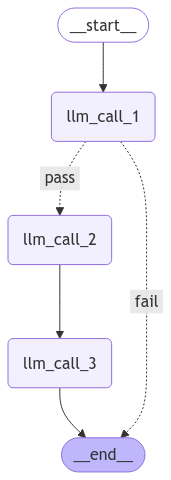

{'messages': [HumanMessage(content='Process this input', additional_kwargs={}, response_metadata={}, id='bee88a5e-9797-4c30-8f7b-bcde2be32a79'), AIMessage(content='Sure, please provide the input you would like me to process.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 26, 'total_tokens': 40, 'completion_time': 0.036802681, 'prompt_time': 0.003699542, 'queue_time': 0.239860822, 'total_time': 0.040502223}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'stop', 'logprobs': None}, id='run-dab68082-be8f-4708-ba66-d291b551f827-0', usage_metadata={'input_tokens': 26, 'output_tokens': 14, 'total_tokens': 40}), AIMessage(content="It seems like you haven't provided any specific input for processing. Could you please give me some details or a specific task you have in mind?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 49, 'total_tokens': 79, 'comp

In [262]:
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph, START
from langchain_core.messages import HumanMessage, SystemMessage
from IPython.display import Image, display

# Initialize LLM
llm = ChatGroq(
    model="qwen-2.5-32b",
    api_key="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"
)

# System message
sys_msg = SystemMessage(content="You are a helpful assistant that processes inputs sequentially.")

# Node definitions
def llm_call_1(state: MessagesState):
    """First LLM call in the sequence"""
    response = llm.invoke([sys_msg] + state["messages"])
    return {"messages": [response], "output": response.content}

def gate_check(state: MessagesState):
    """Gate that checks if the output should pass or fail"""
    # Simple example: check if the output contains "error" or "fail"
    last_output = state["output"]
    should_pass = "error" not in last_output.lower() and "fail" not in last_output.lower()
    return "pass" if should_pass else "fail"

def llm_call_2(state: MessagesState):
    """Second LLM call if gate passes"""
    response = llm.invoke([sys_msg] + state["messages"])
    return {"messages": [response], "output": response.content}

def llm_call_3(state: MessagesState):
    """Third LLM call in the sequence"""
    response = llm.invoke([sys_msg] + state["messages"])
    return {"messages": [response], "output": response.content}

# Graph construction
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("llm_call_1", llm_call_1)
builder.add_node("llm_call_2", llm_call_2)
builder.add_node("llm_call_3", llm_call_3)

# Add edges
builder.add_edge(START, "llm_call_1")

# Add conditional edges from gate
builder.add_conditional_edges(
    "llm_call_1",
    gate_check,
    {
        "pass": "llm_call_2",
        "fail": END
    }
)

builder.add_edge("llm_call_2", "llm_call_3")
builder.add_edge("llm_call_3", END)

# Compile graph
sequential_graph = builder.compile()

# Display the graph visualization
display(Image(sequential_graph.get_graph(xray=True).draw_mermaid_png()))

# Example usage
messages = [HumanMessage(content="Process this input")]
result = sequential_graph.invoke({"messages": messages})
print(result)

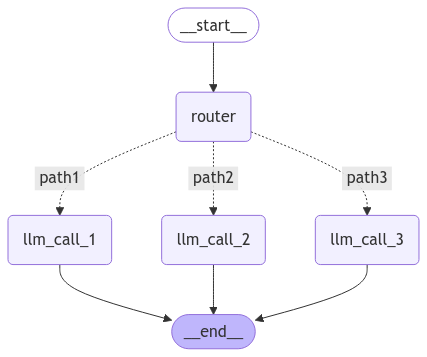

{'messages': [HumanMessage(content='Please analyze this data', additional_kwargs={}, response_metadata={}), AIMessage(content='To properly route your request, could you please specify the type of data you want to be analyzed or the specific aspect of analysis you are interested in? This could relate to textual analysis, statistical data analysis, or any other form of data scrutiny.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 47, 'total_tokens': 97, 'completion_time': 0.126638477, 'prompt_time': 0.004826038, 'queue_time': 0.239086058, 'total_time': 0.131464515}, 'model_name': 'qwen-2.5-32b', 'system_fingerprint': 'fp_35f92f8282', 'finish_reason': 'stop', 'logprobs': None}, id='run-b91b2cae-00ef-4ca7-8487-3f2b9b2c14d5-0', usage_metadata={'input_tokens': 47, 'output_tokens': 50, 'total_tokens': 97}), AIMessage(content="Sure, I'd be happy to help with the analysis. Could you please provide more details about the data and what specifi

In [3]:
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from IPython.display import Image, display
from typing import Literal, TypedDict, Annotated, Sequence, Union
from langchain_core.messages import BaseMessage

# Initialize LLM
llm = ChatGroq(
    model="qwen-2.5-32b",
    api_key="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"
)

# System message
sys_msg = SystemMessage(content="You are a helpful assistant that processes inputs and routes them appropriately.")

# Define state type
class GraphState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], "Chat messages"]
    route: str

# Node definitions
def llm_router(state: GraphState):
    """Router that determines which path to take"""
    response = llm.invoke([
        sys_msg,
        SystemMessage(content="Analyze the input and route to path1, path2, or path3."),
        *state["messages"]
    ])
    
    # Simple routing logic based on content
    content = response.content.lower()
    if "analyze" in content or "analysis" in content:
        route = "path1"
    elif "process" in content or "processing" in content:
        route = "path2"
    else:
        route = "path3"
    
    return {"messages": state["messages"] + [response], "route": route}

def llm_call_1(state: GraphState):
    """First LLM call path"""
    response = llm.invoke([sys_msg] + state["messages"])
    return {"messages": state["messages"] + [response]}

def llm_call_2(state: GraphState):
    """Second LLM call path"""
    response = llm.invoke([sys_msg] + state["messages"])
    return {"messages": state["messages"] + [response]}

def llm_call_3(state: GraphState):
    """Third LLM call path"""
    response = llm.invoke([sys_msg] + state["messages"])
    return {"messages": state["messages"] + [response]}

# Router function for conditional edges
def router_condition(state: GraphState) -> Literal["path1", "path2", "path3"]:
    return state["route"]

# Graph construction
builder = StateGraph(GraphState)

# Add nodes
builder.add_node("router", llm_router)
builder.add_node("llm_call_1", llm_call_1)
builder.add_node("llm_call_2", llm_call_2)
builder.add_node("llm_call_3", llm_call_3)

# Add edges
builder.add_edge(START, "router")

# Add conditional edges from router
builder.add_conditional_edges(
    "router",
    router_condition,
    {
        "path1": "llm_call_1",
        "path2": "llm_call_2",
        "path3": "llm_call_3"
    }
)

# Add edges to end
builder.add_edge("llm_call_1", END)
builder.add_edge("llm_call_2", END)
builder.add_edge("llm_call_3", END)

# Compile graph
router_graph = builder.compile()

# Display the graph visualization
display(Image(router_graph.get_graph(xray=True).draw_mermaid_png()))

# Example usage
messages = [HumanMessage(content="Please analyze this data")]
result = router_graph.invoke({"messages": messages, "route": ""})
print(result)

In [5]:
from langchain_core.messages import HumanMessage, SystemMessage

# Example 1: Analysis request (routes to path1)
analysis_message = [HumanMessage(content="Please analyze the market trends for renewable energy")]
result1 = router_graph.invoke({
    "messages": analysis_message,
    "route": ""
})
print("\nExample 1 - Analysis Request:")
print("Input:", analysis_message[0].content)
print("Route taken:", result1["route"])
for msg in result1["messages"]:
    if isinstance(msg, HumanMessage):
        print("Human:", msg.content)
    else:
        print("Assistant:", msg.content)

# Example 2: Processing request (routes to path2)
processing_message = [HumanMessage(content="Can you process this dataset: [1, 2, 3, 4, 5]")]
result2 = router_graph.invoke({
    "messages": processing_message,
    "route": ""
})
print("\nExample 2 - Processing Request:")
print("Input:", processing_message[0].content)
print("Route taken:", result2["route"])
for msg in result2["messages"]:
    if isinstance(msg, HumanMessage):
        print("Human:", msg.content)
    else:
        print("Assistant:", msg.content)

# Example 3: General query (routes to path3)
general_message = [HumanMessage(content="What's the weather like today?")]
result3 = router_graph.invoke({
    "messages": general_message,
    "route": ""
})
print("\nExample 3 - General Query:")
print("Input:", general_message[0].content)
print("Route taken:", result3["route"])
for msg in result3["messages"]:
    if isinstance(msg, HumanMessage):
        print("Human:", msg.content)
    else:
        print("Assistant:", msg.content)

# Example 4: Multi-turn conversation
conversation = [
    HumanMessage(content="Let's analyze the impact of AI on healthcare"),
    SystemMessage(content="Previous discussion about AI in healthcare"),
    HumanMessage(content="Can you process the trends we discussed?")
]
result4 = router_graph.invoke({
    "messages": conversation,
    "route": ""
})
print("\nExample 4 - Multi-turn Conversation:")
print("Conversation history:", [msg.content for msg in conversation])
print("Route taken:", result4["route"])
for msg in result4["messages"]:
    if isinstance(msg, HumanMessage):
        print("Human:", msg.content)
    else:
        print("Assistant:", msg.content)

# Example 5: Batch processing
questions = [
    "Analyze the global economic outlook",
    "Process this customer feedback",
    "What's the capital of France?"
]

print("\nExample 5 - Batch Processing:")
for question in questions:
    result = router_graph.invoke({
        "messages": [HumanMessage(content=question)],
        "route": ""
    })
    print(f"\nQuestion: {question}")
    print(f"Route taken: {result['route']}")
    print("Response:", result["messages"][-1].content)


Example 1 - Analysis Request:
Input: Please analyze the market trends for renewable energy
Route taken: path1
Human: Please analyze the market trends for renewable energy
Assistant: This input should be routed to **path2**. It appears to require an analysis or research-based response regarding market trends in the renewable energy sector, which typically involves data analysis, trend identification, and possibly forecasting—tasks suited for path2 which likely handles complex queries or requests for detailed analysis.
Assistant: It seems like you might be expecting a brief analysis or some key points regarding market trends in the renewable energy sector. Here are some general insights:

1. **Growth in Renewable Energy Capacity**: There has been a significant increase in the installation of renewable energy capacity globally. Solar and wind energy are leading this growth, driven by improvements in technology and reduction in costs.

2. **Policy and Incentives**: Government policies and